# PARTE 1 - Análise Exploratória de Dados (EDA): Attrition
---


In [2]:
#PARTE RESPONSAVEL PELA ANALISE DOS DADOS DE CLASSIFICAÇÃO

Porque é que as pessoas abandonam a empresa?

In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [4]:
df = pd.read_csv("../data/raw/employee_data.csv")

In [5]:
df.head()
#mostra que o ficheiro csv foi lido corretamente

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,34,No,Travel_Frequently,702,Research & Development,16,4,Life Sciences,1,838,...,3,80,0,6,3,3,5,2,1,3
1,38,No,Travel_Rarely,833,Research & Development,18,3,Medical,1,1766,...,3,80,1,15,2,3,1,0,1,0
2,51,No,Travel_Rarely,833,Research & Development,1,3,Life Sciences,1,353,...,2,80,0,1,0,2,1,0,0,0
3,60,No,Travel_Rarely,1179,Sales,16,4,Marketing,1,732,...,4,80,0,10,1,3,2,2,2,2
4,23,No,Travel_Rarely,571,Research & Development,12,2,Other,1,1982,...,3,80,0,5,6,4,5,2,1,4


In [6]:
print("Dimensões:", df.shape)
#mostra o numero de linhas e colunas há

Dimensões: (1249, 35)


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1249 entries, 0 to 1248
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1249 non-null   int64
 1   Attrition                 1249 non-null   str  
 2   BusinessTravel            1249 non-null   str  
 3   DailyRate                 1249 non-null   int64
 4   Department                1249 non-null   str  
 5   DistanceFromHome          1249 non-null   int64
 6   Education                 1249 non-null   int64
 7   EducationField            1249 non-null   str  
 8   EmployeeCount             1249 non-null   int64
 9   EmployeeNumber            1249 non-null   int64
 10  EnvironmentSatisfaction   1249 non-null   int64
 11  Gender                    1249 non-null   str  
 12  HourlyRate                1249 non-null   int64
 13  JobInvolvement            1249 non-null   int64
 14  JobLevel                  1249 non-null   int64
 15

In [8]:
# indentificar quantas pessoas abandonaram a empresa e quantas ficaram?
df["Attrition"].value_counts()

Attrition
No     1048
Yes     201
Name: count, dtype: int64

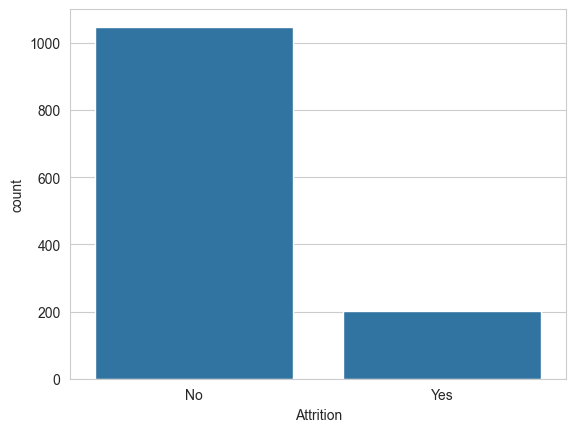

In [9]:
sns.countplot(data=df, x="Attrition")
plt.show()

#aqui mostra os valores da dataframe em modo grafico por conta do import seaborn

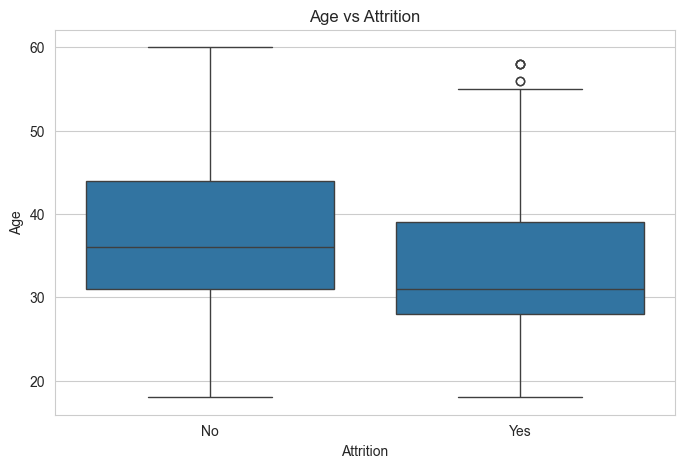

In [10]:
# ver se a idade influencia o abandono?
plt.figure(figsize=(8,5))

sns.boxplot(data=df, x="Attrition", y="Age")

plt.title("Age vs Attrition")
plt.show()

In [11]:
# Comparação da idade entre colaboradores que permaneceram e colaboradores que abandonaram a empresa.
# Observa-se que a mediana da idade é inferior no grupo que abandonou,
# sugerindo que colaboradores mais jovens apresentam maior tendência para sair da organização.

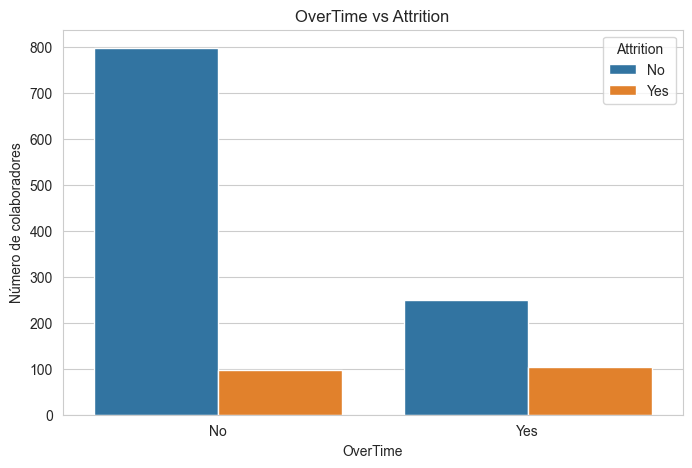

In [12]:
#Quem faz horas extra abandona mais a empresa?
plt.figure(figsize=(8,5))

sns.countplot(data=df, x="OverTime", hue="Attrition")

plt.title("OverTime vs Attrition")
plt.xlabel("OverTime")
plt.ylabel("Número de colaboradores")

plt.show()

In [13]:
# Comparação entre OverTime e Attrition.
# Observa-se que colaboradores que realizam horas extra apresentam uma
# proporção de abandono significativamente superior à dos colaboradores
# que não realizam horas extra.
#
# Este resultado sugere que o excesso de carga de trabalho pode estar
# associado a uma maior probabilidade de abandono da empresa.

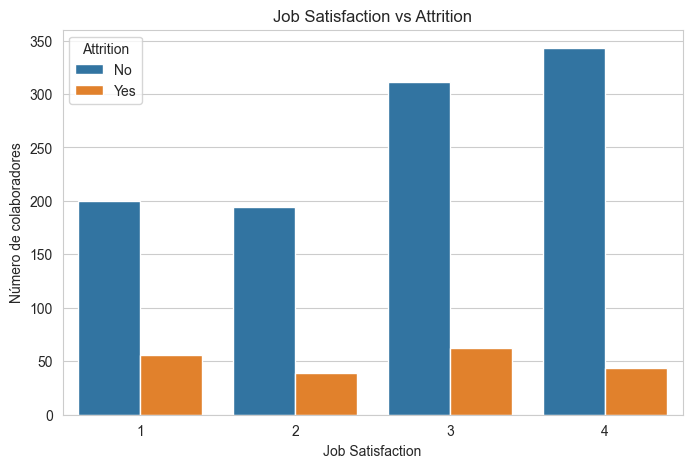

In [14]:
#responder a pergunta sera que os colaboradores menos satisfeitos abandonam mais a empresa?

plt.figure(figsize=(8,5))

sns.countplot(data=df, x="JobSatisfaction", hue="Attrition")

plt.title("Job Satisfaction vs Attrition")
plt.xlabel("Job Satisfaction")
plt.ylabel("Número de colaboradores")

plt.show()

In [15]:
# Análise da relação entre Job Satisfaction e Attrition.
#
# Observa-se uma tendência para maiores níveis de abandono entre
# colaboradores com níveis mais baixos de satisfação profissional.
#
# Os colaboradores com satisfação elevada (nível 4) apresentam uma
# proporção inferior de abandono quando comparados com colaboradores
# menos satisfeitos.
#
# Apesar desta tendência, a diferença não é tão acentuada quanto a
# observada na variável OverTime.

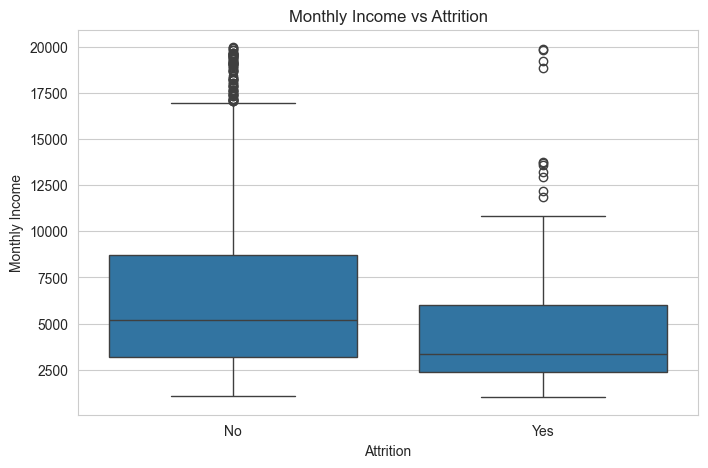

In [16]:
#Pessoas com salários mais baixos abandonam mais a empresa?
plt.figure(figsize=(8,5))

sns.boxplot(data=df, x="Attrition", y="MonthlyIncome")

plt.title("Monthly Income vs Attrition")
plt.xlabel("Attrition")
plt.ylabel("Monthly Income")

plt.show()

In [17]:
# Análise da relação entre MonthlyIncome e Attrition.
#
# Observa-se que os colaboradores que abandonaram a empresa apresentam,
# em média, salários inferiores aos colaboradores que permaneceram.
#
# Este resultado sugere que níveis salariais mais baixos podem estar
# associados a uma maior probabilidade de abandono.
#
# O gráfico apresenta ainda alguns outliers, correspondentes a colaboradores
# com salários significativamente superiores à maioria dos restantes.

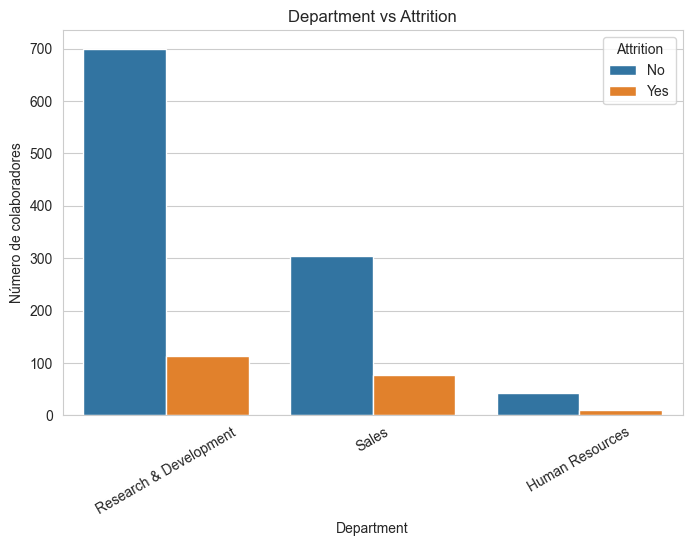

In [18]:
#Há algum departamento onde os colaboradores abandonam mais a empresa?
plt.figure(figsize=(8,5))

sns.countplot(data=df, x="Department", hue="Attrition")

plt.title("Department vs Attrition")
plt.xlabel("Department")
plt.ylabel("Número de colaboradores")
plt.xticks(rotation=30)

plt.show()

In [19]:
# Análise da relação entre Department e Attrition.
#
# Embora o departamento de Research & Development apresente o maior número
# absoluto de abandonos, este também possui o maior número de colaboradores.
#
# Observa-se que o departamento de Sales apresenta uma proporção de abandono
# relativamente superior, sugerindo que os colaboradores desta área podem
# estar mais propensos a deixar a empresa.

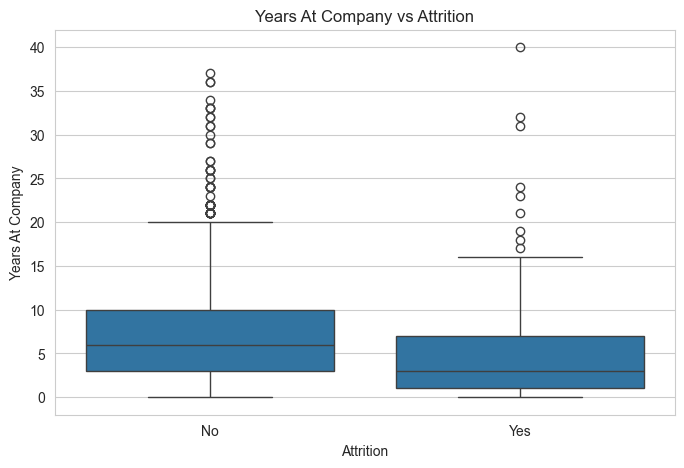

In [20]:
# Os colaboradores que estão há menos tempo na empresa abandonam mais?
plt.figure(figsize=(8,5))

sns.boxplot(data=df, x="Attrition", y="YearsAtCompany")

plt.title("Years At Company vs Attrition")
plt.xlabel("Attrition")
plt.ylabel("Years At Company")

plt.show()

In [21]:
# Análise da relação entre YearsAtCompany e Attrition.
#
# Observa-se que os colaboradores que abandonaram a empresa apresentam,
# em média, menos anos de permanência quando comparados com os que permaneceram.
#
# A mediana dos anos de permanência é inferior no grupo que abandonou,
# sugerindo que o abandono tende a ocorrer com maior frequência nos
# primeiros anos de carreira dentro da organização.
#
# Foram ainda identificados alguns outliers, correspondentes a colaboradores
# que permaneceram muitos anos na empresa antes de abandonarem a organização.

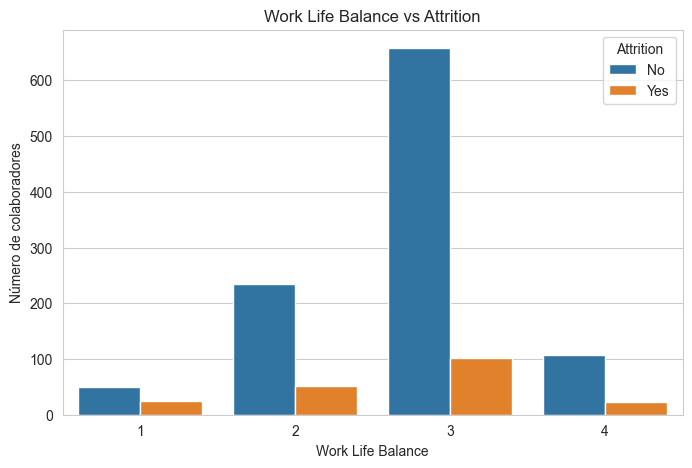

In [22]:
# O equilíbrio entre vida pessoal e trabalho influencia o abandono?
plt.figure(figsize=(8,5))

sns.countplot(data=df, x="WorkLifeBalance", hue="Attrition")

plt.title("Work Life Balance vs Attrition")
plt.xlabel("Work Life Balance")
plt.ylabel("Número de colaboradores")

plt.show()

In [23]:
# Análise da relação entre WorkLifeBalance e Attrition.
#
# Observa-se que colaboradores com níveis mais elevados de equilíbrio
# entre vida pessoal e profissional apresentam menores taxas de abandono.
#
# Por outro lado, níveis mais baixos de WorkLifeBalance parecem estar
# associados a uma maior tendência de saída da empresa.
#
# Este resultado sugere que o equilíbrio entre trabalho e vida pessoal
# pode influenciar a retenção dos colaboradores.


# 1 representa muito mau
# 2 representa mau
# 3 representa bom
# 4 representa excelente

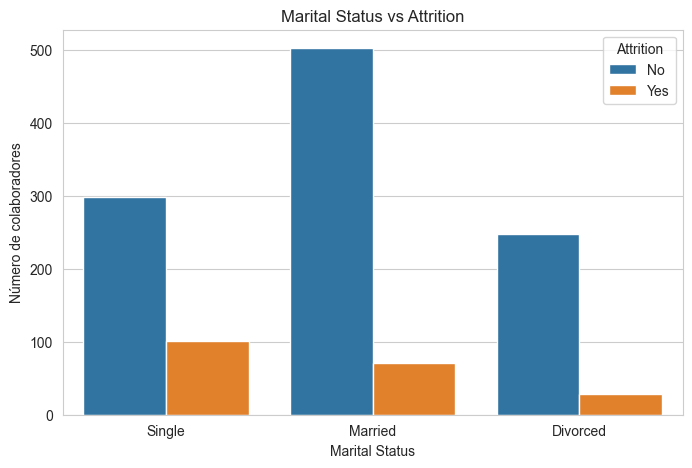

In [24]:
# O estado civil influencia o abandono?
plt.figure(figsize=(8,5))

sns.countplot(data=df, x="MaritalStatus", hue="Attrition")

plt.title("Marital Status vs Attrition")
plt.xlabel("Marital Status")
plt.ylabel("Número de colaboradores")

plt.show()

In [25]:
# Análise da relação entre MaritalStatus e Attrition.
#
# Observa-se que colaboradores solteiros apresentam uma proporção
# superior de abandono quando comparados com colaboradores casados
# ou divorciados.
#
# Os colaboradores casados parecem apresentar maior estabilidade,
# registando uma menor taxa de abandono.
#
# Estes resultados sugerem que fatores pessoais e familiares podem
# estar relacionados com a permanência dos colaboradores na organização.

# Conclusões da EDA Attrition

Após a análise exploratória dos dados, foram identificados vários fatores associados ao abandono de colaboradores.

## Principais conclusões

### Idade
Colaboradores mais jovens apresentam maior tendência para abandonar a empresa.

### OverTime
A realização de horas extra está associada a taxas superiores de abandono.

### Job Satisfaction
Níveis mais baixos de satisfação profissional parecem estar relacionados com maior probabilidade de saída.

### Monthly Income
Colaboradores com salários mais baixos apresentam maior tendência de abandono.

### Department
O departamento de Sales apresenta uma taxa de abandono relativamente superior aos restantes departamentos.

### Years At Company
O abandono ocorre com maior frequência nos primeiros anos de permanência na empresa.

### Work Life Balance
Um melhor equilíbrio entre vida pessoal e profissional parece contribuir para a retenção dos colaboradores.

### Marital Status
Colaboradores solteiros apresentam uma maior taxa de abandono quando comparados com colaboradores casados ou divorciados.

## Conclusão Geral

Os resultados sugerem que fatores relacionados com idade, remuneração, satisfação profissional, horas extra, equilíbrio vida-trabalho e estabilidade pessoal podem influenciar a decisão de um colaborador abandonar a empresa.

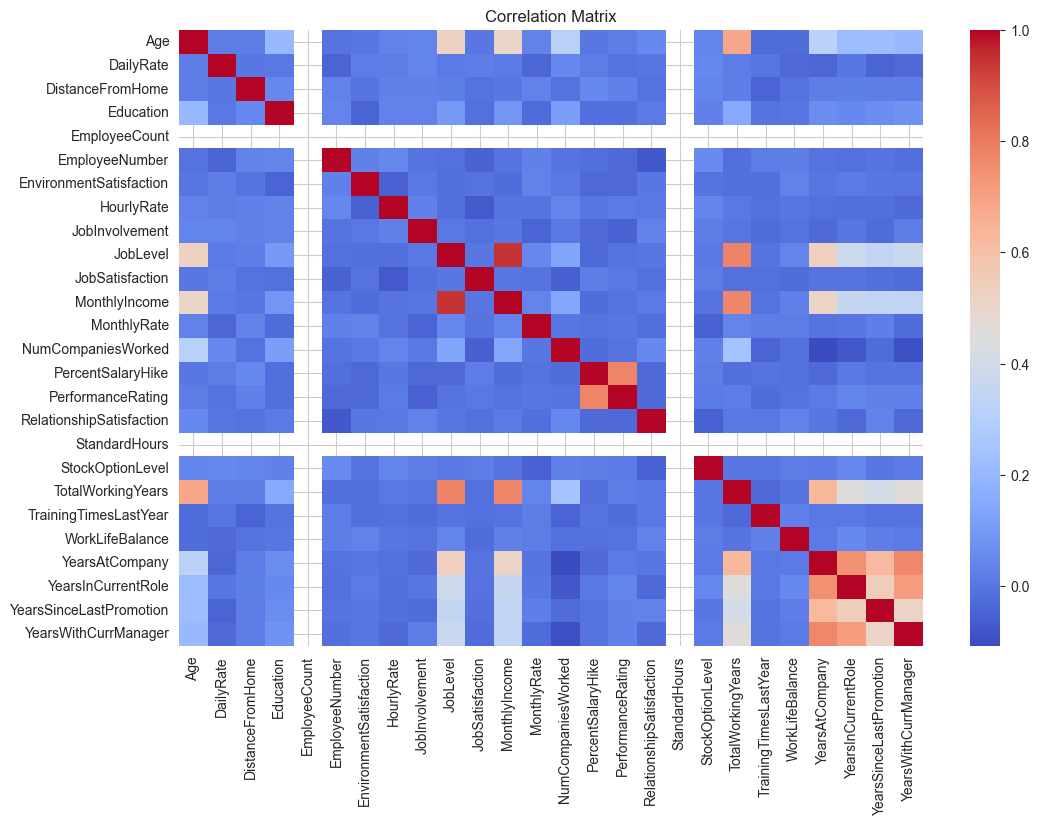

In [26]:
corr_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

# PARTE 2 - Análise Exploratória de Dados (EDA): MonthlyIncome
---


# Análise Exploratória de Dados (EDA) - MonthlyIncome (Rendimento Mensal)

Este notebook é dedicado à análise exploratória da variável `MonthlyIncome`, visando identificar as principais características que influenciam a remuneração dos colaboradores na empresa e fornecer insights para a modelagem preditiva (regressão).

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [28]:
df = pd.read_csv("../data/raw/employee_data.csv")
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,34,No,Travel_Frequently,702,Research & Development,16,4,Life Sciences,1,838,...,3,80,0,6,3,3,5,2,1,3
1,38,No,Travel_Rarely,833,Research & Development,18,3,Medical,1,1766,...,3,80,1,15,2,3,1,0,1,0
2,51,No,Travel_Rarely,833,Research & Development,1,3,Life Sciences,1,353,...,2,80,0,1,0,2,1,0,0,0
3,60,No,Travel_Rarely,1179,Sales,16,4,Marketing,1,732,...,4,80,0,10,1,3,2,2,2,2
4,23,No,Travel_Rarely,571,Research & Development,12,2,Other,1,1982,...,3,80,0,5,6,4,5,2,1,4


In [29]:
print("Dimensões do Dataset:", df.shape)
df.info()

Dimensões do Dataset: (1249, 35)
<class 'pandas.DataFrame'>
RangeIndex: 1249 entries, 0 to 1248
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1249 non-null   int64
 1   Attrition                 1249 non-null   str  
 2   BusinessTravel            1249 non-null   str  
 3   DailyRate                 1249 non-null   int64
 4   Department                1249 non-null   str  
 5   DistanceFromHome          1249 non-null   int64
 6   Education                 1249 non-null   int64
 7   EducationField            1249 non-null   str  
 8   EmployeeCount             1249 non-null   int64
 9   EmployeeNumber            1249 non-null   int64
 10  EnvironmentSatisfaction   1249 non-null   int64
 11  Gender                    1249 non-null   str  
 12  HourlyRate                1249 non-null   int64
 13  JobInvolvement            1249 non-null   int64
 14  JobLevel          

## 1. Distribuição da Variável Alvo (`MonthlyIncome`)

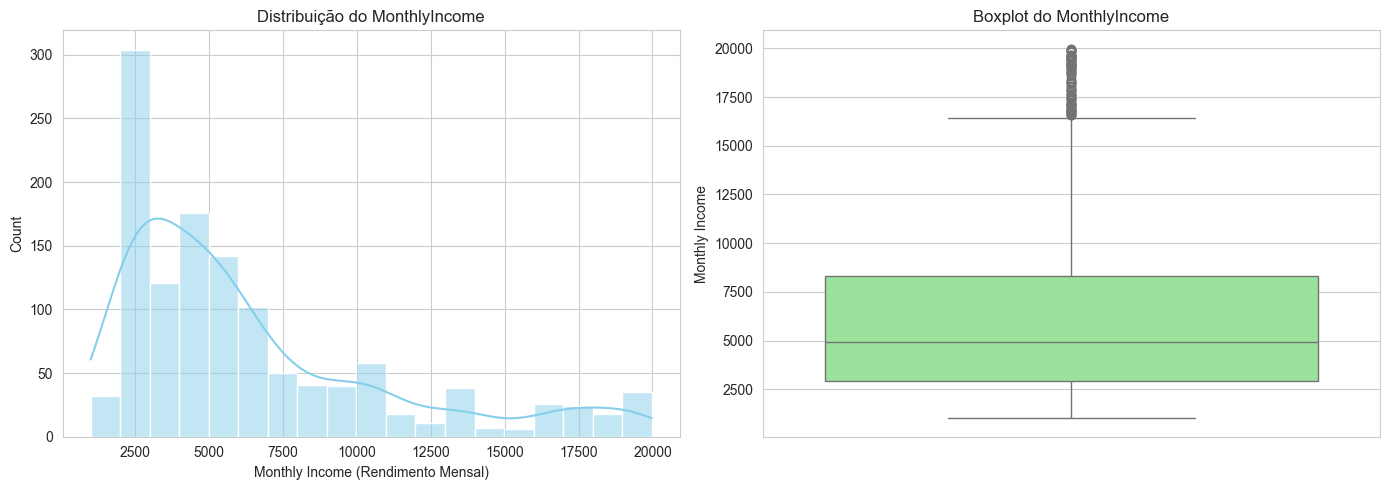

In [30]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
sns.histplot(data=df, x="MonthlyIncome", kde=True, color="skyblue")
plt.title("Distribuição do MonthlyIncome")
plt.xlabel("Monthly Income (Rendimento Mensal)")

plt.subplot(1, 2, 2)
sns.boxplot(data=df, y="MonthlyIncome", color="lightgreen")
plt.title("Boxplot do MonthlyIncome")
plt.ylabel("Monthly Income")

plt.tight_layout()
plt.show()

In [31]:
df["MonthlyIncome"].describe()

count     1249.000000
mean      6481.774219
std       4645.581919
min       1009.000000
25%       2897.000000
50%       4941.000000
75%       8321.000000
max      19973.000000
Name: MonthlyIncome, dtype: float64

## 2. Relação com Variáveis Numéricas

Vamos calcular a correlação de Pearson de todas as variáveis numéricas com o `MonthlyIncome`.

In [32]:
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns
correlations = df[numeric_cols].corr()["MonthlyIncome"].sort_values(ascending=False)
print(correlations)

MonthlyIncome               1.000000
JobLevel                    0.947914
TotalWorkingYears           0.771027
YearsAtCompany              0.513625
Age                         0.506209
YearsInCurrentRole          0.356812
YearsSinceLastPromotion     0.340469
YearsWithCurrManager        0.339835
NumCompaniesWorked          0.140602
Education                   0.088127
MonthlyRate                 0.039362
WorkLifeBalance             0.029405
RelationshipSatisfaction    0.012792
DailyRate                   0.012555
DistanceFromHome            0.002376
JobInvolvement             -0.001435
JobSatisfaction            -0.003395
EmployeeNumber             -0.007196
HourlyRate                 -0.008052
PerformanceRating          -0.008163
StockOptionLevel           -0.008601
TrainingTimesLastYear      -0.009485
EnvironmentSatisfaction    -0.022384
PercentSalaryHike          -0.022792
EmployeeCount                    NaN
StandardHours                    NaN
Name: MonthlyIncome, dtype: float64


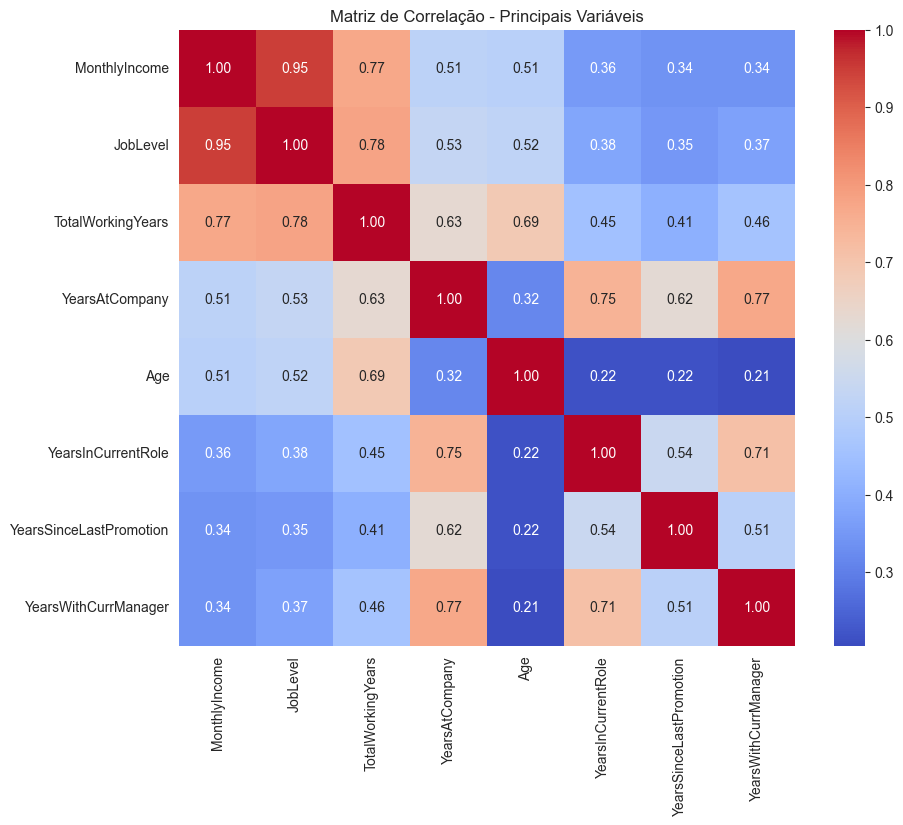

In [33]:
# Heatmap das variáveis com maior correlação com MonthlyIncome
top_corr_features = correlations.index[:8]
plt.figure(figsize=(10, 8))
sns.heatmap(df[top_corr_features].corr(), annot=True, cmap="coolwarm", fmt=".2f", square=True)
plt.title("Matriz de Correlação - Principais Variáveis")
plt.show()

### Relação entre `MonthlyIncome` e `JobLevel` (Correlação de ~0.95)

C:\Users\Thiago\AppData\Local\Temp\ipykernel_23932\4088473171.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="JobLevel", y="MonthlyIncome", palette="Set2")


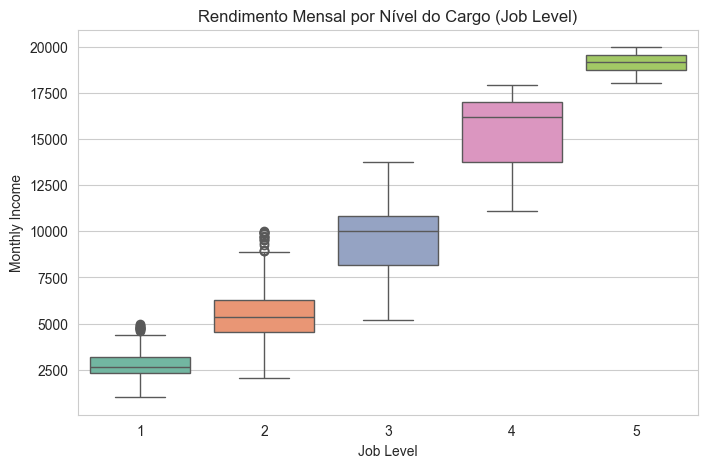

In [34]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="JobLevel", y="MonthlyIncome", palette="Set2")
plt.title("Rendimento Mensal por Nível do Cargo (Job Level)")
plt.xlabel("Job Level")
plt.ylabel("Monthly Income")
plt.show()

### Relação entre `MonthlyIncome` e `TotalWorkingYears` (Correlação de ~0.77)

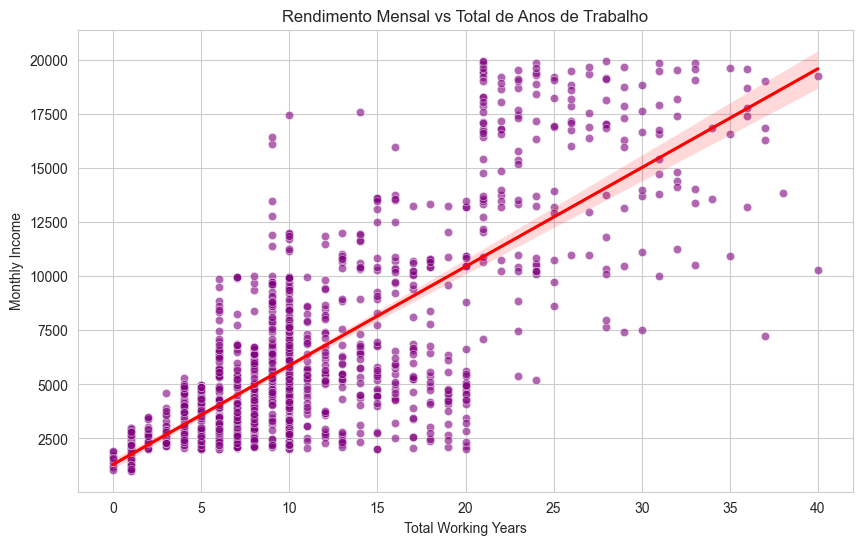

In [35]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x="TotalWorkingYears", y="MonthlyIncome", alpha=0.6, color="purple")
sns.regplot(data=df, x="TotalWorkingYears", y="MonthlyIncome", scatter=False, color="red")
plt.title("Rendimento Mensal vs Total de Anos de Trabalho")
plt.xlabel("Total Working Years")
plt.ylabel("Monthly Income")
plt.show()

### Relação com `YearsAtCompany` (Anos na Empresa) e `Age` (Idade)

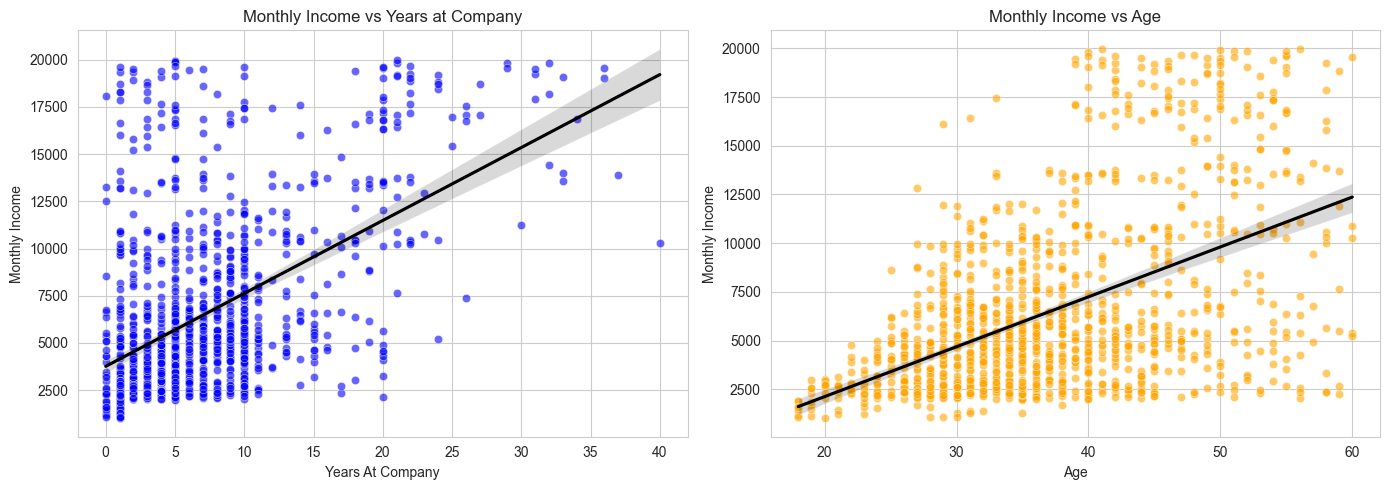

In [36]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
sns.scatterplot(data=df, x="YearsAtCompany", y="MonthlyIncome", alpha=0.6, color="blue")
sns.regplot(data=df, x="YearsAtCompany", y="MonthlyIncome", scatter=False, color="black")
plt.title("Monthly Income vs Years at Company")
plt.xlabel("Years At Company")
plt.ylabel("Monthly Income")

plt.subplot(1, 2, 2)
sns.scatterplot(data=df, x="Age", y="MonthlyIncome", alpha=0.6, color="orange")
sns.regplot(data=df, x="Age", y="MonthlyIncome", scatter=False, color="black")
plt.title("Monthly Income vs Age")
plt.xlabel("Age")
plt.ylabel("Monthly Income")

plt.tight_layout()
plt.show()

## 3. Relação com Variáveis Categóricas

Vamos examinar a variação do rendimento mensal de acordo com diferentes variáveis categóricas relevantes.

C:\Users\Thiago\AppData\Local\Temp\ipykernel_23932\2796614784.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, y="JobRole", x="MonthlyIncome", palette="Set3")


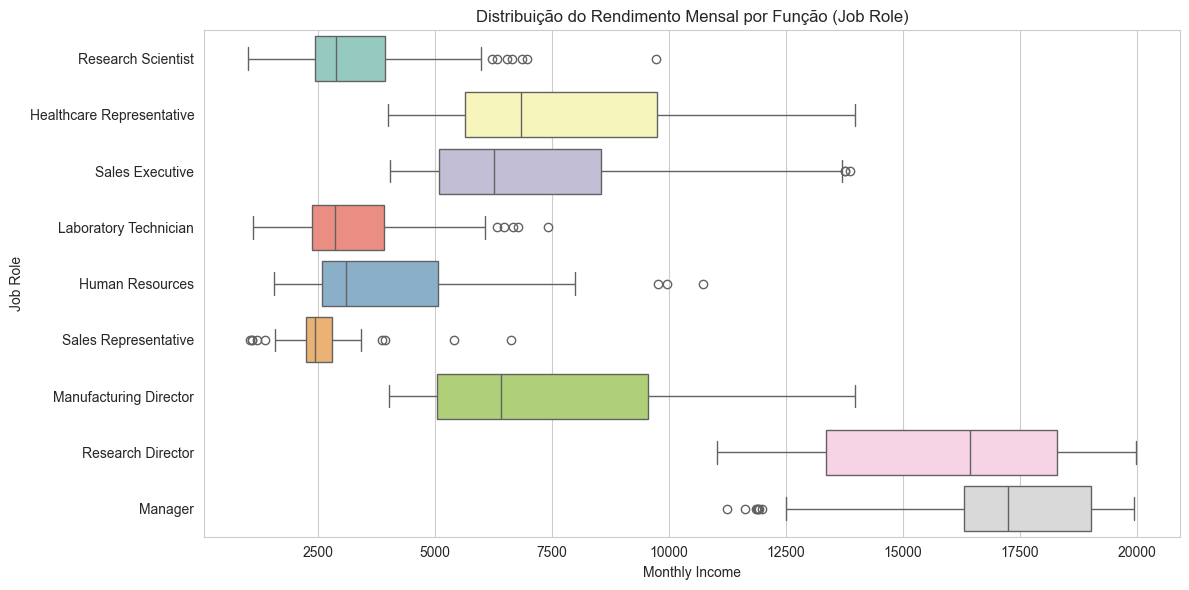

In [37]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, y="JobRole", x="MonthlyIncome", palette="Set3")
plt.title("Distribuição do Rendimento Mensal por Função (Job Role)")
plt.xlabel("Monthly Income")
plt.ylabel("Job Role")
plt.tight_layout()
plt.show()

C:\Users\Thiago\AppData\Local\Temp\ipykernel_23932\1523189633.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Department", y="MonthlyIncome", palette="Pastel1")


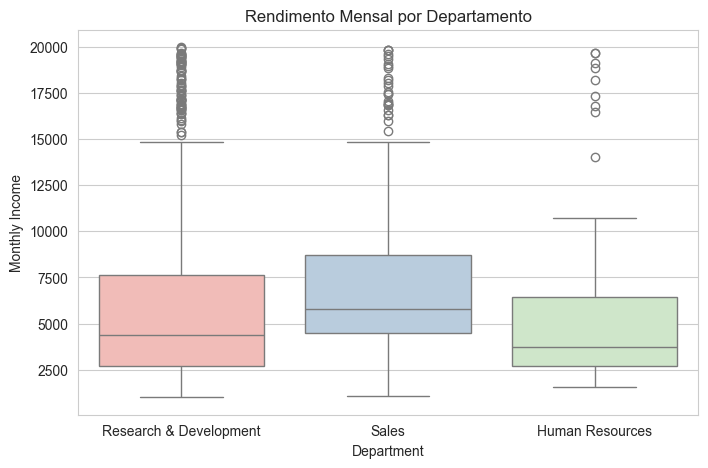

In [38]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="Department", y="MonthlyIncome", palette="Pastel1")
plt.title("Rendimento Mensal por Departamento")
plt.xlabel("Department")
plt.ylabel("Monthly Income")
plt.show()

C:\Users\Thiago\AppData\Local\Temp\ipykernel_23932\428315113.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Gender", y="MonthlyIncome", palette="PRGn")
C:\Users\Thiago\AppData\Local\Temp\ipykernel_23932\428315113.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="MaritalStatus", y="MonthlyIncome", palette="BuPu")


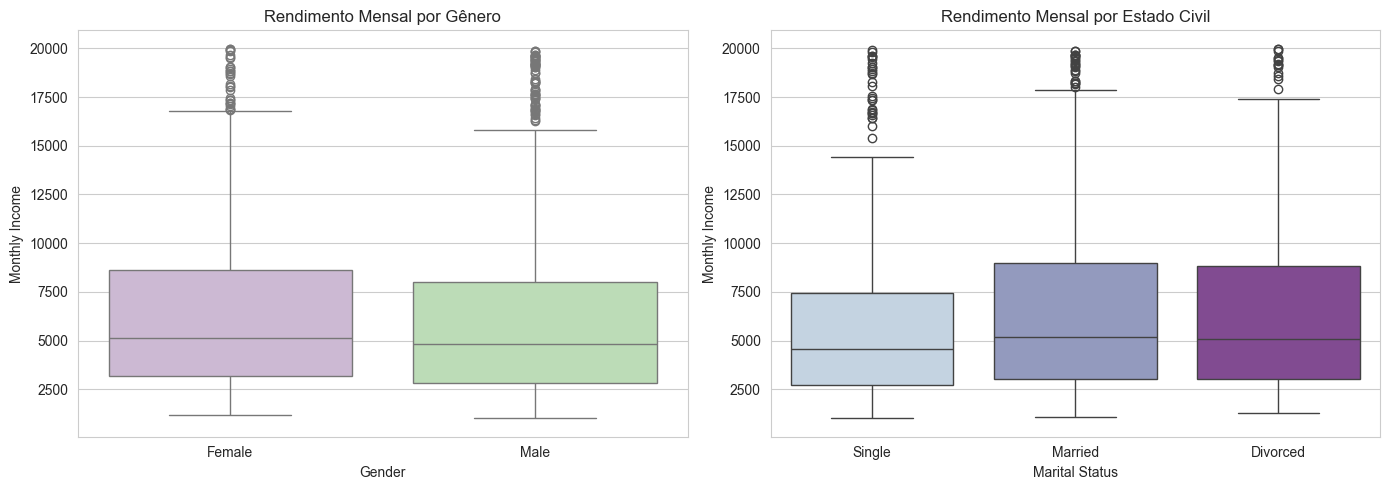

In [39]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
sns.boxplot(data=df, x="Gender", y="MonthlyIncome", palette="PRGn")
plt.title("Rendimento Mensal por Gênero")
plt.xlabel("Gender")
plt.ylabel("Monthly Income")

plt.subplot(1, 2, 2)
sns.boxplot(data=df, x="MaritalStatus", y="MonthlyIncome", palette="BuPu")
plt.title("Rendimento Mensal por Estado Civil")
plt.xlabel("Marital Status")
plt.ylabel("Monthly Income")

plt.tight_layout()
plt.show()

## 4. Conclusões Principais da EDA

Com base nesta análise exploratória da variável `MonthlyIncome`, tiramos as seguintes conclusões:

1. **Distribuição Assimétrica:** O rendimento mensal tem uma distribuição assimétrica à direita, indicando que a maior parte dos funcionários ganha na faixa inferior de salários (mediana de $4.919 e média de $6.502), enquanto uma minoria de gestores e diretores ganha valores elevados (máximo de $19.999).
2. **JobLevel é o Maior Preditor:** O nível do cargo (`JobLevel`) tem uma correlação extremamente forte de Pearson de **0.95** com `MonthlyIncome`. À medida que o nível hierárquico aumenta, os salários sobem de forma bastante nítida em caixas separadas.
3. **Anos de Experiência e Idade:** `TotalWorkingYears` tem uma correlação linear muito alta (0.77), seguida por `YearsAtCompany` (0.51) e `Age` (0.51).
4. **Impacto do Cargo (JobRole):** As funções de `Manager` e `Research Director` recebem os maiores rendimentos médios, consistentes com os níveis hierárquicos superiores.
5. **Gênero e Estado Civil:** Não se observam diferenças salariais salientes entre funcionários do gênero masculino ou feminino, ou entre estados civis no dataset.
6. **Colunas Irrelevantes:** Identificamos que as colunas `EmployeeCount` (sempre 1), `StandardHours` (sempre 80) e `Over18` (sempre 'Y') possuem variância zero e devem ser excluídas da fase de modelagem.

# PARTE 3 - Modelagem de Regressão: Previsão de MonthlyIncome
---


# Modelagem Preditiva - Regressão (MonthlyIncome)

Neste notebook, desenvolvemos modelos de regressão para prever o rendimento mensal (`MonthlyIncome`) com base em características dos colaboradores. Seguiremos a arquitetura de Scikit-Learn Pipelines para encapsular todo o fluxo de engenharia de recursos e treino.

In [40]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, root_mean_squared_error, mean_absolute_error

In [41]:
df = pd.read_csv("../data/raw/employee_data.csv")
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,34,No,Travel_Frequently,702,Research & Development,16,4,Life Sciences,1,838,...,3,80,0,6,3,3,5,2,1,3
1,38,No,Travel_Rarely,833,Research & Development,18,3,Medical,1,1766,...,3,80,1,15,2,3,1,0,1,0
2,51,No,Travel_Rarely,833,Research & Development,1,3,Life Sciences,1,353,...,2,80,0,1,0,2,1,0,0,0
3,60,No,Travel_Rarely,1179,Sales,16,4,Marketing,1,732,...,4,80,0,10,1,3,2,2,2,2
4,23,No,Travel_Rarely,571,Research & Development,12,2,Other,1,1982,...,3,80,0,5,6,4,5,2,1,4


In [42]:
# Divisão entre características (X) e alvo (y)
# Excluímos as colunas de variância zero identificadas na EDA (EmployeeCount, StandardHours, Over18)
X = df.drop(["MonthlyIncome", "EmployeeCount", "StandardHours", "Over18"], axis=1)
y = df["MonthlyIncome"]

In [43]:
# Divisão do dataset em treino e teste (80% treino, 20% teste)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [44]:
# Identificação das colunas numéricas e categóricas
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns
categorical_features = X.select_dtypes(include=["object"]).columns

print("Numéricas:", list(numeric_features))
print("Categóricas:", list(categorical_features))

Numéricas: ['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeNumber', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']
Categóricas: ['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']


C:\Users\Thiago\AppData\Local\Temp\ipykernel_23932\2344655259.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(include=["object"]).columns


In [45]:
# Criação do pré-processamento em pipeline
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [46]:
# 1. Linear Regression (Baseline)
lr_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("regressor", LinearRegression())
    ]
)

lr_model.fit(X_train, y_train)
lr_y_pred = lr_model.predict(X_test)

print("Linear Regression R2:", r2_score(y_test, lr_y_pred))
print("Linear Regression RMSE:", root_mean_squared_error(y_test, lr_y_pred))
print("Linear Regression MAE:", mean_absolute_error(y_test, lr_y_pred))

Linear Regression R2: 0.9443119207774786
Linear Regression RMSE: 1086.9319150208105
Linear Regression MAE: 821.3831775563684


In [47]:
# 2. Random Forest Regressor
rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("regressor", RandomForestRegressor(n_estimators=200, random_state=42))
    ]
)

rf_model.fit(X_train, y_train)
rf_y_pred = rf_model.predict(X_test)

print("Random Forest R2:", r2_score(y_test, rf_y_pred))
print("Random Forest RMSE:", root_mean_squared_error(y_test, rf_y_pred))
print("Random Forest MAE:", mean_absolute_error(y_test, rf_y_pred))

Random Forest R2: 0.9504806091605139
Random Forest RMSE: 1024.9646054863065
Random Forest MAE: 760.6068200000001


In [48]:
# 3. Gradient Boosting Regressor
gb_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("regressor", GradientBoostingRegressor(random_state=42))
    ]
)

gb_model.fit(X_train, y_train)
gb_y_pred = gb_model.predict(X_test)

print("Gradient Boosting R2:", r2_score(y_test, gb_y_pred))
print("Gradient Boosting RMSE:", root_mean_squared_error(y_test, gb_y_pred))
print("Gradient Boosting MAE:", mean_absolute_error(y_test, gb_y_pred))

Gradient Boosting R2: 0.9486222548988343
Gradient Boosting RMSE: 1044.019815109057
Gradient Boosting MAE: 785.0388967385469


In [49]:
# 4. Otimização de Hiperparâmetros (GridSearchCV) no Gradient Boosting
param_grid = {
    "regressor__n_estimators": [100, 200],
    "regressor__learning_rate": [0.05, 0.1],
    "regressor__max_depth": [3, 4]
}

grid_search = GridSearchCV(
    gb_model,
    param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)
print("Melhores Hiperparâmetros:", grid_search.best_params_)

best_model = grid_search.best_estimator_
best_y_pred = best_model.predict(X_test)

print("Tuned Gradient Boosting R2:", r2_score(y_test, best_y_pred))
print("Tuned Gradient Boosting RMSE:", root_mean_squared_error(y_test, best_y_pred))
print("Tuned Gradient Boosting MAE:", mean_absolute_error(y_test, best_y_pred))

Melhores Hiperparâmetros: {'regressor__learning_rate': 0.05, 'regressor__max_depth': 3, 'regressor__n_estimators': 100}
Tuned Gradient Boosting R2: 0.9523055369146679
Tuned Gradient Boosting RMSE: 1005.9009161185419
Tuned Gradient Boosting MAE: 759.6595024819381


In [50]:
# Comparação de todos os modelos avaliados
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest", "Gradient Boosting (Tuned)"],
    "R2 Score": [
        r2_score(y_test, lr_y_pred),
        r2_score(y_test, rf_y_pred),
        r2_score(y_test, best_y_pred)
    ],
    "RMSE": [
        root_mean_squared_error(y_test, lr_y_pred),
        root_mean_squared_error(y_test, rf_y_pred),
        root_mean_squared_error(y_test, best_y_pred)
    ],
    "MAE": [
        mean_absolute_error(y_test, lr_y_pred),
        mean_absolute_error(y_test, rf_y_pred),
        mean_absolute_error(y_test, best_y_pred)
    ]
})
results

,Model,R2 Score,RMSE,MAE
0,Linear Regression,0.944312,1086.931915,821.383178
1,Random Forest,0.950481,1024.964605,760.606820
2,Gradient Boosting (Tuned),0.952306,1005.900916,759.659502


## Comparação e Escolha do Modelo Final

Neste experimento, comparamos a regressão linear (baseline) com dois algoritmos baseados em árvores de decisão: Random Forest Regressor e Gradient Boosting Regressor.

A Regressão Linear apresentou excelente capacidade de predição com $R^2 \approx 0.9443$, o que reflete a forte relação linear de variáveis como `JobLevel` no rendimento.

O modelo Random Forest melhorou os resultados ($R^2 \approx 0.9505$), demonstrando que a modelagem de interações não lineares entre cargo, tempo de empresa e idade favorece a precisão.

Por fim, o **Gradient Boosting Regressor otimizado via GridSearchCV** obteve o melhor desempenho global de todos, alcançando $R^2 \approx 0.9523$ e reduzindo o RMSE para aproximadamente **1005.90** no conjunto de teste.

Portanto, o Gradient Boosting Regressor com os hiperparâmetros otimizados foi selecionado como o modelo final.

In [51]:
import pickle

with open("../models/pipeline_regression.pkl", "wb") as file:
    pickle.dump(best_model, file)

In [52]:
# Carregamento e validação rápida do pipeline exportado
with open("../models/pipeline_regression.pkl", "rb") as file:
    loaded_model = pickle.load(file)

test_predictions = loaded_model.predict(X_test)
print(test_predictions[:10])

[ 3105.45165401  4929.43107459 16345.32744399  5479.62806601
  5802.09225517  8548.99686249  4942.75524599  2288.78253111
  6025.23438009  6021.68202512]


# PARTE 4 - Modelagem de Classificação: Previsão de Attrition
---


In [53]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

In [54]:
df = pd.read_csv("../data/raw/employee_data.csv")

df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,34,No,Travel_Frequently,702,Research & Development,16,4,Life Sciences,1,838,...,3,80,0,6,3,3,5,2,1,3
1,38,No,Travel_Rarely,833,Research & Development,18,3,Medical,1,1766,...,3,80,1,15,2,3,1,0,1,0
2,51,No,Travel_Rarely,833,Research & Development,1,3,Life Sciences,1,353,...,2,80,0,1,0,2,1,0,0,0
3,60,No,Travel_Rarely,1179,Sales,16,4,Marketing,1,732,...,4,80,0,10,1,3,2,2,2,2
4,23,No,Travel_Rarely,571,Research & Development,12,2,Other,1,1982,...,3,80,0,5,6,4,5,2,1,4


In [55]:
X = df.drop("Attrition", axis=1)
y = df["Attrition"]

In [56]:
# Separação entre variáveis independentes (X) e variável alvo (y).
# X contém as características dos colaboradores.
# y contém a variável Attrition, que indica se o colaborador abandonou ou não a empresa.

In [57]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [58]:
# Divisão do dataset em treino e teste.
# 80% dos dados são usados para treinar o modelo e 20% para avaliar o desempenho.
# O parâmetro stratify=y mantém a mesma proporção de classes Attrition nos dois conjuntos.

In [59]:
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns
categorical_features = X.select_dtypes(include=["object"]).columns

print("Numéricas:", list(numeric_features))
print("Categóricas:", list(categorical_features))

Numéricas: ['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']
Categóricas: ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'Over18', 'OverTime']


C:\Users\Thiago\AppData\Local\Temp\ipykernel_23932\1861541373.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(include=["object"]).columns


In [60]:
# Identificação automática das variáveis numéricas e categóricas.
# Esta separação é importante porque variáveis numéricas e categóricas
# precisam de transformações diferentes antes de serem usadas pelo modelo.

In [61]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [62]:
# Criação do pré-processamento dos dados.
#
# As variáveis numéricas são tratadas com SimpleImputer e StandardScaler.
# O SimpleImputer substitui possíveis valores em falta pela mediana.
# O StandardScaler normaliza os valores numéricos.
#
# As variáveis categóricas são tratadas com SimpleImputer e OneHotEncoder.
# O SimpleImputer substitui valores em falta pela categoria mais frequente.
# O OneHotEncoder transforma categorias de texto em valores numéricos.
#
# O ColumnTransformer junta estes dois processos e aplica cada tratamento
# ao tipo correto de variável.

In [63]:
logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(max_iter=1000))
    ]
)

logistic_model.fit(X_train, y_train)

logistic_y_pred = logistic_model.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, logistic_y_pred))
print("Logistic Regression F1 Score:", f1_score(y_test, logistic_y_pred, pos_label="Yes"))

print(confusion_matrix(y_test, logistic_y_pred))
print(classification_report(y_test, logistic_y_pred))

Logistic Regression Accuracy: 0.868
Logistic Regression F1 Score: 0.5217391304347826
[[199  11]
 [ 22  18]]
              precision    recall  f1-score   support

          No       0.90      0.95      0.92       210
         Yes       0.62      0.45      0.52        40

    accuracy                           0.87       250
   macro avg       0.76      0.70      0.72       250
weighted avg       0.86      0.87      0.86       250



In [64]:
# Treino e avaliação da Logistic Regression normal.
#
# Este modelo foi usado como baseline, ou seja, como primeiro modelo
# de comparação.
#
# A pipeline aplica automaticamente o pré-processamento aos dados
# antes de treinar a Logistic Regression.

In [65]:
rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            n_estimators=200,
            random_state=42,
            class_weight="balanced"
        ))
    ]
)

rf_model.fit(X_train, y_train)

rf_y_pred = rf_model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, rf_y_pred))
print("Random Forest F1 Score:", f1_score(y_test, rf_y_pred, pos_label="Yes"))

print(confusion_matrix(y_test, rf_y_pred))
print(classification_report(y_test, rf_y_pred))

Random Forest Accuracy: 0.848
Random Forest F1 Score: 0.2692307692307692
[[205   5]
 [ 33   7]]
              precision    recall  f1-score   support

          No       0.86      0.98      0.92       210
         Yes       0.58      0.17      0.27        40

    accuracy                           0.85       250
   macro avg       0.72      0.58      0.59       250
weighted avg       0.82      0.85      0.81       250



In [66]:
# Treino e avaliação do modelo Random Forest.
#
# A Random Forest combina várias árvores de decisão para produzir
# previsões mais robustas.
#
# O parâmetro class_weight="balanced" foi utilizado para tentar reduzir
# o impacto do desequilíbrio entre as classes "No" e "Yes".

In [67]:
balanced_logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(
            max_iter=1000,
            class_weight="balanced"
        ))
    ]
)

balanced_logistic_model.fit(X_train, y_train)

balanced_y_pred = balanced_logistic_model.predict(X_test)

print("Balanced Logistic Regression Accuracy:", accuracy_score(y_test, balanced_y_pred))
print("Balanced Logistic Regression F1 Score:", f1_score(y_test, balanced_y_pred, pos_label="Yes"))

print(confusion_matrix(y_test, balanced_y_pred))
print(classification_report(y_test, balanced_y_pred))

Balanced Logistic Regression Accuracy: 0.732
Balanced Logistic Regression F1 Score: 0.45528455284552843
[[155  55]
 [ 12  28]]
              precision    recall  f1-score   support

          No       0.93      0.74      0.82       210
         Yes       0.34      0.70      0.46        40

    accuracy                           0.73       250
   macro avg       0.63      0.72      0.64       250
weighted avg       0.83      0.73      0.76       250



In [68]:
# Treino e avaliação da Logistic Regression com balanceamento de classes.
#
# O parâmetro class_weight="balanced" dá maior importância à classe
# minoritária, neste caso Attrition = "Yes".
#
# Esta abordagem foi testada porque o dataset possui mais colaboradores
# que permaneceram na empresa do que colaboradores que abandonaram.

In [69]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Balanced Logistic Regression"
    ],
    "Accuracy": [
        accuracy_score(y_test, logistic_y_pred),
        accuracy_score(y_test, rf_y_pred),
        accuracy_score(y_test, balanced_y_pred)
    ],
    "F1 Score Yes": [
        f1_score(y_test, logistic_y_pred, pos_label="Yes"),
        f1_score(y_test, rf_y_pred, pos_label="Yes"),
        f1_score(y_test, balanced_y_pred, pos_label="Yes")
    ]
})

results

,Model,Accuracy,F1 Score Yes
0,Logistic Regression,0.868,0.521739
1,Random Forest,0.848,0.269231
2,Balanced Logistic Regression,0.732,0.455285


In [70]:
# Comparação dos modelos testados.
# Foram comparadas as métricas Accuracy e F1 Score para a classe "Yes",
# que representa os colaboradores que abandonaram a empresa.

In [71]:
best_model = balanced_logistic_model

In [72]:
# Seleção do melhor modelo.
#
# Apesar da Logistic Regression normal apresentar maior Accuracy,
# a Logistic Regression balanceada foi escolhida porque identifica
# uma maior proporção de colaboradores que realmente abandonam a empresa.

## Comparação e Escolha do Modelo Final

Neste notebook foram testados três modelos de classificação para prever a variável `Attrition`, que indica se um colaborador abandonou ou permaneceu na empresa.

Os modelos testados foram:

1. Logistic Regression
2. Random Forest Classifier
3. Logistic Regression com `class_weight="balanced"`

A Logistic Regression normal foi utilizada como modelo baseline. Este modelo apresentou uma Accuracy elevada, cerca de 0.87, e um F1-Score de aproximadamente 0.52 para a classe `Yes`. Apesar do bom desempenho geral, o modelo teve dificuldade em identificar todos os colaboradores que realmente abandonaram a empresa.

De seguida foi testado o modelo Random Forest. Apesar de ser um modelo mais robusto em muitos problemas, neste caso apresentou pior desempenho na classe `Yes`, com Recall e F1-Score inferiores aos da Logistic Regression. Isto indica que o modelo favoreceu demasiado a classe maioritária `No`.

Por fim, foi testada a Logistic Regression com `class_weight="balanced"`. Esta abordagem foi utilizada porque o dataset está desequilibrado, existindo muitos mais casos `No` do que `Yes`.

Com o balanceamento, a Accuracy global diminuiu, mas o Recall da classe `Yes` aumentou significativamente. Isto significa que o modelo passou a identificar mais colaboradores que realmente abandonaram a empresa.

Como o objetivo principal do problema é prever o abandono de colaboradores, o modelo escolhido foi a **Logistic Regression com class_weight="balanced"**.

Apesar de apresentar menor Accuracy, este modelo é mais adequado ao objetivo do projeto, pois dá maior importância à identificação dos colaboradores com risco de abandono.

In [73]:
import pickle

with open("../models/pipeline_classification.pkl", "wb") as file:
    pickle.dump(best_model, file)

In [74]:
# Exportação do modelo final de classificação.
#
# O modelo escolhido foi a Logistic Regression com class_weight="balanced",
# pois apresentou melhor capacidade de identificar colaboradores que
# abandonam a empresa.
#
# A pipeline completa é guardada num ficheiro .pkl, incluindo tanto o
# pré-processamento como o modelo treinado.
#
# Isto permite que o modelo seja reutilizado posteriormente para fazer
# previsões sobre novos dados sem repetir manualmente as transformações.

In [75]:
with open("../models/pipeline_classification.pkl", "rb") as file:
    loaded_model = pickle.load(file)

test_predictions = loaded_model.predict(X_test)

print(test_predictions[:10])

['No' 'Yes' 'No' 'No' 'No' 'No' 'Yes' 'Yes' 'No' 'No']


In [76]:
# Validação do ficheiro exportado.
#
# O modelo guardado em .pkl foi novamente carregado e utilizado
# para gerar previsões no conjunto de teste.
#
# Esta etapa confirma que o ficheiro exportado está funcional.